In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from collections import defaultdict

FONTSIZE  = 32
LINEWIDTH = 3

plt.rcParams.update({
    "font.size":             FONTSIZE,
    "axes.labelsize":        FONTSIZE,
    "axes.titlesize":        FONTSIZE,
    "xtick.labelsize":       FONTSIZE - 4,
    "ytick.labelsize":       FONTSIZE - 4,
    "legend.fontsize":       FONTSIZE - 8,
    "legend.title_fontsize": FONTSIZE - 6,
    "axes.linewidth":        1.5,
    "xtick.major.width":     1.5,
    "ytick.major.width":     1.5,
    "xtick.major.size":      6,
    "ytick.major.size":      6,
})

In [9]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR = '../data'
MODEL    = 'complete_model_extreme_fav'
SMOOTH   = 5

FAVILA_DIR     = os.path.join(DATA_DIR, 'favila2016_nopred',            MODEL)
CHANALES21_DIR = os.path.join(DATA_DIR, 'chanales2021_exp1_v3',  MODEL)
CHANALES17_DIR = os.path.join(DATA_DIR, 'chanales2017_sim1',     MODEL)

# Chanales 2021 conditions
C21_CONDITIONS = {
    'ultra_sim': 'ultra',
    'high_sim': 'high',
    'med_sim':  'mod.',
    'low_sim':  'low',
}
C21_COLORS = {
    'ultra_sim': 'tab:green',
    'high_sim': 'tab:red',
    'med_sim':  '#FFD700',
    'low_sim':  'tab:blue',
}

# Chanales 2017 network colors (as specified)
C17_NET_COLORS = {0: '#e5e289', 1: '#89e590'}

# Favila subgroup colors (from favila_analysis.ipynb)
FAVILA_SG_COLORS = {
    'no face':        'grey',
    'different face': 'red',
    'same face':      'blue',
}
FAVILA_LABELS = {
    'no face':        'No',
    'different face': 'Diff.',
    'same face':      'Same',
}

# Network labels (used across all panels)
NET_LABELS = {0: 'Dense\nnetwork', 1: 'Sparse\nnetwork'}

In [10]:
# ── Favila helpers ────────────────────────────────────────────────────────────

def within_minus_between_similarity(representations, rows_meta):
    subgroups = list(dict.fromkeys(r['subgroup'] for r in rows_meta))
    indices_by_sg = {
        sg: np.array([i for i, r in enumerate(rows_meta) if r['subgroup'] == sg])
        for sg in subgroups
    }
    group_ids_by_sg = {
        sg: np.array([rows_meta[i]['group_id'] for i in idxs])
        for sg, idxs in indices_by_sg.items()
    }
    result = {}
    for sg in subgroups:
        idxs      = indices_by_sg[sg]
        group_ids = group_ids_by_sg[sg]
        same_group = group_ids[:, None] == group_ids[None, :]
        np.fill_diagonal(same_group, False)
        diff_group = ~same_group
        np.fill_diagonal(diff_group, False)
        scores = np.empty(representations.shape[0])
        for t in range(representations.shape[0]):
            reps    = representations[t][idxs]
            cosim   = np.corrcoef(reps, rowvar=True)
            within  = cosim[same_group].mean() if same_group.any() else 0.0
            between = cosim[diff_group].mean() if diff_group.any() else 0.0
            scores[t] = within - between
        result[sg] = scores
    return result


def _detect_networks(run_dir, probe_name, layer_key):
    prefix = f'{probe_name}_net'
    suffix = f'_{layer_key}.npy'
    return sorted(
        int(f[len(prefix):-len(suffix)])
        for f in os.listdir(run_dir)
        if f.startswith(prefix) and f.endswith(suffix)
           and f[len(prefix):-len(suffix)].isdigit()
    )


def _load_run(run_dir, probe_name, layer_key, net_indices):
    with open(os.path.join(run_dir, f'{probe_name}_rows.json')) as f:
        rows_meta = json.load(f)
    steps = np.load(os.path.join(run_dir, f'{probe_name}_steps.npy'))
    reps_by_net = {
        ni: np.load(os.path.join(run_dir, f'{probe_name}_net{ni}_{layer_key}.npy'))
        for ni in net_indices
    }
    return reps_by_net, rows_meta, steps


def plot_favila_endpoint_panel(multirun_dir, net_idx, ax, title=None,
                                probe='representations', layer='hidden_0'):
    """End-of-training within-minus-between similarity per subgroup (dot + SEM CI)."""
    run_dirs = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
           and os.path.isfile(os.path.join(multirun_dir, d, f'{probe}_rows.json'))
    ])
    net_indices = _detect_networks(run_dirs[0], probe, layer)

    seed_scores = {}   # sg -> list of one scalar per seed
    sg_order = None
    for run_dir in run_dirs:
        reps_by_net, rows_meta, _ = _load_run(run_dir, probe, layer, net_indices)
        reps_final = reps_by_net[net_idx][-1:]   # (1, n_items, hidden)
        scores = within_minus_between_similarity(reps_final, rows_meta)
        if sg_order is None:
            sg_order = list(scores.keys())
        for sg, arr in scores.items():
            seed_scores.setdefault(sg, []).append(arr[0])

    subgroups = sg_order or list(seed_scores.keys())
    x_pos = np.arange(len(subgroups))
    for xi, sg in enumerate(subgroups):
        vals  = np.array(seed_scores[sg])
        mean  = vals.mean()
        sem   = vals.std() / np.sqrt(len(vals))
        label = sg.replace('_', ' ')
        color = FAVILA_SG_COLORS.get(label, 'black')
        ax.plot([xi, xi], [mean - sem, mean + sem],
                color=color, lw=LINEWIDTH, solid_capstyle='round', zorder=4)
        ax.plot(xi, mean, 'o', color=color, markersize=14, zorder=5)

    ax.axhline(0, color='0.5', linestyle='--', linewidth=2, zorder=1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([FAVILA_LABELS[sg.replace('_', ' ')] for sg in subgroups])
    ax.set_ylabel('Pair similarity')
    if title:
        ax.set_title(title)


In [11]:
# ── Chanales 2021 helpers ─────────────────────────────────────────────────────

def _signed_angle(origin, target, x):
    e1 = origin / np.linalg.norm(origin)
    v  = target - np.dot(target, e1) * e1
    e2 = v / np.linalg.norm(v)
    def _angle(y):
        return np.arctan2(np.dot(y, e2), np.dot(y, e1))
    wrap = lambda a: (a + np.pi) % (2 * np.pi) - np.pi
    return -np.degrees(np.sign(wrap(_angle(target) - _angle(origin))) * wrap(_angle(x) - _angle(origin)))


def plot_chanales21_endpoint_panel(multirun_dir, conditions, colors, ax,
                                    n_epochs, probe='prediction', slot='color'):
    """End-of-training proportion-positive repulsion per condition (dot + Wilson CI).

    Parameters
    ----------
    n_epochs : int
        Number of training epochs — used to locate the final epoch-end checkpoint.
        For chanales2021_exp1: ``epochs: 8`` in configs/schedule/chanales2021_exp1.yaml.
    """
    if isinstance(conditions, list):
        conditions = {sg: sg for sg in conditions}
    if isinstance(colors, list):
        colors = {sg: c for sg, c in zip(conditions.keys(), colors)}

    seed_dirs_list = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
    ], key=lambda p: int(os.path.basename(p)) if os.path.basename(p).isdigit() else float('inf'))

    cond_vals = {sg: [] for sg in conditions}   # sg -> flat list of final-epoch metric values

    for sd in seed_dirs_list:
        pred_f  = os.path.join(sd, f'{probe}_combined_{slot}.npy')
        gt_f    = os.path.join(sd, f'{probe}_target_{slot}.npy')
        rows_f  = os.path.join(sd, f'{probe}_rows.json')
        steps_f = os.path.join(sd, f'{probe}_steps.npy')
        if not all(os.path.exists(p) for p in (pred_f, gt_f, rows_f, steps_f)):
            continue
        prediction   = np.load(pred_f)
        ground_truth = np.load(gt_f)
        steps_arr    = np.load(steps_f)
        with open(rows_f) as f:
            row_info = json.load(f)

        n_groups = ground_truth.shape[0] // 2
        metric   = np.empty((len(steps_arr), len(row_info)))
        for t in range(len(steps_arr)):
            vals = []
            for i in range(n_groups):
                gt1, gt2     = ground_truth[2*i], ground_truth[2*i+1]
                pred1, pred2 = prediction[t, 2*i], prediction[t, 2*i+1]
                vals.extend([_signed_angle(gt1, gt2, pred1), _signed_angle(gt2, gt1, pred2)])
            metric[t] = vals

        # final epoch-end checkpoint
        epoch_end_idx = (
            np.linspace(len(steps_arr) / n_epochs, len(steps_arr), n_epochs, endpoint=True)
            .astype(int) - 1
        )
        final_metric = metric[epoch_end_idx[-1]]   # (n_items,)

        for sg in conditions:
            mask = np.array([r['subgroup'] == sg for r in row_info])
            if mask.any():
                cond_vals[sg].extend(final_metric[mask].tolist())

    # x-axis order: low → med → high → ultra (skip absent)
    _order = ['low_sim', 'med_sim', 'high_sim', 'ultra_sim']
    ordered = [sg for sg in _order if sg in conditions]
    ordered += [sg for sg in conditions if sg not in ordered]

    x_pos = np.arange(len(ordered))
    z = 1.96
    for xi, sg in enumerate(ordered):
        vals  = np.array(cond_vals[sg])
        succ  = (vals > 0).sum()
        n     = np.sum(np.isfinite(vals) & (vals != 0))
        p     = succ / n
        denom = 1 + z**2 / n
        centre = (p + z**2 / (2*n)) / denom
        half   = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
        color  = colors.get(sg, 'black')
        ax.plot([xi, xi], [centre - half, centre + half],
                color=color, lw=LINEWIDTH, solid_capstyle='round', zorder=4)
        ax.plot(xi, p, 'o', color=color, markersize=14, zorder=5)

    ax.axhline(0.5, color='0.5', linestyle='--', linewidth=2, zorder=1)
    ax.set_ylim(0, 1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([conditions[sg] for sg in ordered])
    ax.set_ylabel('Response Away\nFrom Competitor')


In [34]:
# ── Chanales 2017 helpers ─────────────────────────────────────────────────────

C17_COLOR_OVERLAP    = '#22678e'
C17_COLOR_NOOVERLAP  = '#de6139'


def _final_within_between(run_dir, net_idx, probe='representations', layer='hidden_0'):
    """Return (within_sim, between_sim) scalars from the final training step."""
    reps = np.load(os.path.join(run_dir, f'{probe}_net{net_idx}_{layer}.npy'))
    with open(os.path.join(run_dir, f'{probe}_rows.json')) as f:
        rows = json.load(f)

    sim = np.corrcoef(reps[-1])   # final step, (n_samples, n_samples)

    groups = defaultdict(list)
    for i, r in enumerate(rows):
        groups[(r['subgroup'], r['group_id'])].append(i)
    group_lists = list(groups.values())

    w_vals, b_vals = [], []
    for gi, g1 in enumerate(group_lists):
        for a in range(len(g1)):
            for b_ in range(a + 1, len(g1)):
                w_vals.append(sim[g1[a], g1[b_]])
        for g2 in group_lists[gi + 1:]:
            for i1 in g1:
                for i2 in g2:
                    b_vals.append(sim[i1, i2])
    return np.mean(w_vals), np.mean(b_vals)


def plot_chanales17_bar_panel(multirun_dir, net_idx, ax,
                               probe='representations', layer='hidden_0', legend=True):
    """Bar chart of final-step overlapping vs non-overlapping route similarity."""
    run_dirs_list = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
    ])

    overlap_vals, nooverlap_vals = [], []
    for sd in run_dirs_list:
        try:
            w, b = _final_within_between(sd, net_idx, probe, layer)
        except FileNotFoundError:
            print(sd)
            continue
        overlap_vals.append(w)
        nooverlap_vals.append(b)

    overlap_arr   = np.array(overlap_vals)
    nooverlap_arr = np.array(nooverlap_vals)
    print(overlap_arr)

    means  = [overlap_arr[~np.isnan(overlap_arr)].mean(),   nooverlap_arr[~np.isnan(overlap_arr)].mean()]
    sems   = [overlap_arr[~np.isnan(overlap_arr)].std()   / np.sqrt(len(overlap_arr[~np.isnan(overlap_arr)])),
              nooverlap_arr[~np.isnan(overlap_arr)].std() / np.sqrt(len(nooverlap_arr[~np.isnan(overlap_arr)]))]
    print(means)
    print(sems)
    bar_colors  = [C17_COLOR_OVERLAP, C17_COLOR_NOOVERLAP]
    bar_labels  = ['Overlapping', 'Non-overlapping']

    x = np.arange(len(bar_labels))
    for xi, (mean, sem, color, label) in enumerate(zip(means, sems, bar_colors, bar_labels)):
        ax.plot([xi, xi], [mean - sem, mean + sem],
                color=color, lw=LINEWIDTH, solid_capstyle='round', zorder=4)
        ax.plot(xi, mean, 'o', color=color, markersize=14, zorder=5, label=label)
    ax.set_xticks([])
    ax.axhline(0, color='0.5', linestyle='--', linewidth=2, zorder=1)
    ax.set_ylabel('Similarity')
    if legend:
        ax.legend(frameon=False, loc='upper right')


../data/chanales2017_sim1/complete_model_extreme_fav/.submitit
[0.6183921         nan 0.61231475 0.54304217 0.65424374 0.51831347
 0.5013806  0.63114198 0.6069981  0.54489602 0.64779391 0.67629842
 0.49662792 0.60240339 0.68785885 0.6778865  0.60342195 0.46383376
 0.57870835 0.50807295 0.69571467 0.3590761  0.52713763 0.50083709
 0.59677706 0.75191462 0.55436115 0.41081012 0.3699629  0.45692607
 0.67103903 0.58500713 0.59651635 0.70831564 0.68620914 0.50813572
 0.62148907 0.58404795 0.39649603 0.67059097]
[0.5749998303456528, -0.0450546957405619]
[0.015373793579420904, 0.0169119670564937]
../data/chanales2017_sim1/complete_model_extreme_fav/.submitit
[-0.11872849         nan  0.00530624 -0.14641636 -0.16675569 -0.26912416
 -0.09407576 -0.26092688 -0.23814452  0.06115863 -0.08291279 -0.1072094
 -0.09475046 -0.03086524 -0.14990947 -0.17368204  0.01076274 -0.03837069
 -0.09135415 -0.05003604 -0.23553007 -0.01424934 -0.14473739 -0.12742307
 -0.08592345 -0.16435841 -0.10145258 -0.15330093  

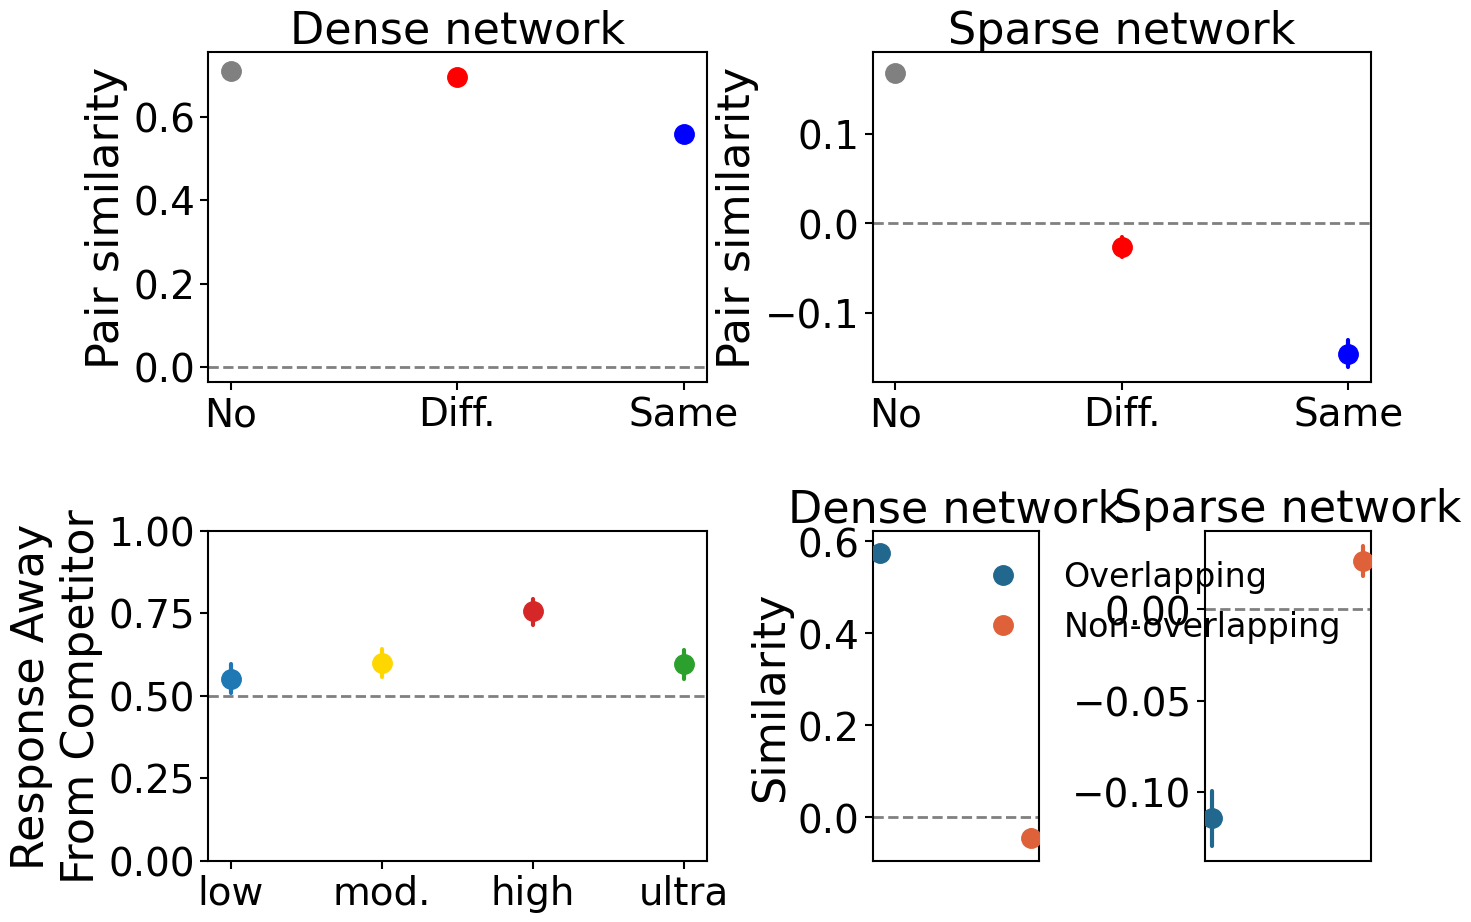

In [36]:
# ── Save three separate figures ───────────────────────────────────────────────
C21_N_EPOCHS = 8
os.makedirs('../figures', exist_ok=True)

# ── 1. Favila (two panels side-by-side, slightly narrower) ────────────────────
fig, (ax_tl, ax_tr) = plt.subplots(1, 2, figsize=(12, 5.5))
fig.subplots_adjust(wspace=0.5)

plot_favila_endpoint_panel(FAVILA_DIR, net_idx=0, ax=ax_tl, title='Dense network')
plot_favila_endpoint_panel(FAVILA_DIR, net_idx=1, ax=ax_tr, title='Sparse network')
ax_tr.set_ylabel('')

plt.savefig('../figures/favila.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── 2. Chanales 2021 (single panel, slightly narrower) ──────────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))

plot_chanales21_endpoint_panel(CHANALES21_DIR, C21_CONDITIONS, C21_COLORS, ax=ax,
                                n_epochs=C21_N_EPOCHS)

plt.savefig('../figures/chanales2021.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── 3. Chanales 2017 (two panels, wider with breathing room for dots) ─────────
fig, (ax_br0, ax_br1) = plt.subplots(1, 2, figsize=(9, 5.5))
fig.subplots_adjust(wspace=0.4)

plot_chanales17_bar_panel(CHANALES17_DIR, net_idx=0, ax=ax_br0, legend=False)
ax_br0.set_title('Dense network')
ax_br0.set_xlim(-0.8, 1.8)

plot_chanales17_bar_panel(CHANALES17_DIR, net_idx=1, ax=ax_br1, legend=True)
ax_br1.set_title('Sparse network')
ax_br1.set_ylabel('')
ax_br1.set_xlim(-0.8, 1.8)

plt.savefig('../figures/chanales2017.pdf', bbox_inches='tight', dpi=300)
plt.show()